<a href="https://colab.research.google.com/github/KavindaKGD/Franklin-Models/blob/ProtoNet/ProtoNet%2BResNet_18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os, random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TF:", tf.__version__)


TF: 2.19.0


In [ ]:
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [ ]:
DATA_ROOT = "/content/drive/MyDrive/fp_dataset"
TRAIN_DIR = os.path.join(DATA_ROOT, "train")
VAL_DIR   = os.path.join(DATA_ROOT, "val")

CLASS_NAMES = ["fp", "healthy", "barnacles"]  # must match folder names
N_WAY = 3

for c in CLASS_NAMES:
    print(c, "train:", len(os.listdir(os.path.join(TRAIN_DIR, c))),
             "val:", len(os.listdir(os.path.join(VAL_DIR, c))))


fp train: 4 val: 2
healthy train: 4 val: 2
barnacles train: 4 val: 2


In [ ]:
def list_images_by_class(base_dir, class_names):
    by_class = {}
    for idx, cname in enumerate(class_names):
        cdir = os.path.join(base_dir, cname)
        files = []
        for f in os.listdir(cdir):
            if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):
                files.append(os.path.join(cdir, f))
        by_class[idx] = sorted(files)
    return by_class

train_by_class = list_images_by_class(TRAIN_DIR, CLASS_NAMES)
val_by_class   = list_images_by_class(VAL_DIR, CLASS_NAMES)

print("Train by class:", {k: len(v) for k, v in train_by_class.items()})
print("Val by class:", {k: len(v) for k, v in val_by_class.items()})


Train by class: {0: 4, 1: 4, 2: 4}
Val by class: {0: 2, 1: 2, 2: 2}


In [ ]:
IMG_SIZE = 224

augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.10),
])

def load_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0
    return img


In [ ]:
def resnet_basic_block(x, filters, stride=1, name="block"):
    shortcut = x

    x = tf.keras.layers.Conv2D(filters, 3, strides=stride, padding="same",
                               use_bias=False, name=name+"_conv1")(x)
    x = tf.keras.layers.BatchNormalization(name=name+"_bn1")(x)
    x = tf.keras.layers.ReLU(name=name+"_relu1")(x)

    x = tf.keras.layers.Conv2D(filters, 3, strides=1, padding="same",
                               use_bias=False, name=name+"_conv2")(x)
    x = tf.keras.layers.BatchNormalization(name=name+"_bn2")(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = tf.keras.layers.Conv2D(filters, 1, strides=stride, padding="same",
                                          use_bias=False, name=name+"_down_conv")(shortcut)
        shortcut = tf.keras.layers.BatchNormalization(name=name+"_down_bn")(shortcut)

    x = tf.keras.layers.Add(name=name+"_add")([x, shortcut])
    x = tf.keras.layers.ReLU(name=name+"_out")(x)
    return x

def build_resnet18_encoder(embedding_dim=128, dropout=0.2):
    inp = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image")

    # Stem
    x = tf.keras.layers.Conv2D(64, 7, strides=2, padding="same", use_bias=False, name="stem_conv")(inp)
    x = tf.keras.layers.BatchNormalization(name="stem_bn")(x)
    x = tf.keras.layers.ReLU(name="stem_relu")(x)
    x = tf.keras.layers.MaxPool2D(pool_size=3, strides=2, padding="same", name="stem_pool")(x)

    # [2,2,2,2]
    x = resnet_basic_block(x, 64,  stride=1, name="s1_b1")
    x = resnet_basic_block(x, 64,  stride=1, name="s1_b2")

    x = resnet_basic_block(x, 128, stride=2, name="s2_b1")
    x = resnet_basic_block(x, 128, stride=1, name="s2_b2")

    x = resnet_basic_block(x, 256, stride=2, name="s3_b1")
    x = resnet_basic_block(x, 256, stride=1, name="s3_b2")

    x = resnet_basic_block(x, 512, stride=2, name="s4_b1")
    x = resnet_basic_block(x, 512, stride=1, name="s4_b2")

    x = tf.keras.layers.GlobalAveragePooling2D(name="gap")(x)
    if dropout and dropout > 0:
        x = tf.keras.layers.Dropout(dropout, name="drop")(x)

    x = tf.keras.layers.Dense(embedding_dim, name="emb_dense")(x)
    out = tf.keras.layers.Lambda(lambda t: tf.math.l2_normalize(t, axis=-1),
                                 name="l2norm")(x)

    return tf.keras.Model(inp, out, name="ResNet18_Encoder")

encoder = build_resnet18_encoder(embedding_dim=128, dropout=0.2)
encoder.summary()


Model: "ResNet18_Encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │      9,408 │ image[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        256 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_relu (ReLU)    │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_pool           │ (None, 56, 56,    │          0 │ stem_relu[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_b1_conv1         │ (None, 56, 56,    │     36,864 │ stem_pool[0][0]   │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_b1_bn1           │ (None, 56, 56,    │        256 │ s1_b1_conv1[0][0] │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_b1_relu1 (ReLU)  │ (None, 56, 56,    │          0 │ s1_b1_bn1[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_b1_conv2         │ (None, 56, 56,    │     36,864 │ s1_b1_relu1[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_b1_bn2           │ (None, 56, 56,    │        256 │ s1_b1_conv2[0][0] │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_b1_add (Add)     │ (None, 56, 56,    │          0 │ s1_b1_bn2[0][0],  │
│                     │ 64)               │            │ stem_pool[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_b1_out (ReLU)    │ (None, 56, 56,    │          0 │ s1_b1_add[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_b2_conv1         │ (None, 56, 56,    │     36,864 │ s1_b1_out[0][0]   │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_b2_bn1           │ (None, 56, 56,    │        256 │ s1_b2_conv1[0][0] │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_b2_relu1 (ReLU)  │ (None, 56, 56,    │          0 │ s1_b2_bn1[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_b2_conv2         │ (None, 56, 56,    │     36,864 │ s1_b2_relu1[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_b2_bn2           │ (None, 56, 56,    │        256 │ s1_b2_conv2[0][0

 Total params: 11,251,776 (42.92 MB)

 Trainable params: 11,242,176 (42.89 MB)

 Non-trainable params: 9,600 (37.50 KB)

In [ ]:
K_SHOT = 1
Q_QUERY = 1

def sample_episode(by_class, k_shot, q_query, training=True):
    support_imgs, support_labels = [], []
    query_imgs, query_labels = [], []

    for c in range(N_WAY):
        files = by_class[c]
        chosen = random.sample(files, k_shot + q_query)

        support_files = chosen[:k_shot]
        query_files   = chosen[k_shot:]

        for p in support_files:
            img = load_image(p)
            if training:
                img = augment(img, training=True)
            support_imgs.append(img)
            support_labels.append(c)

        for p in query_files:
            img = load_image(p)
            if training:
                img = augment(img, training=True)
            query_imgs.append(img)
            query_labels.append(c)

    support_imgs = tf.stack(support_imgs)  # (N*K, H, W, 3)
    query_imgs   = tf.stack(query_imgs)    # (N*Q, H, W, 3)
    support_labels = tf.convert_to_tensor(support_labels, dtype=tf.int32)
    query_labels   = tf.convert_to_tensor(query_labels, dtype=tf.int32)

    return support_imgs, support_labels, query_imgs, query_labels


In [ ]:
def prototypical_logits(encoder, support_imgs, support_labels, query_imgs, training=True):
    z_support = encoder(support_imgs, training=training)  # (N*K, D)
    z_query   = encoder(query_imgs, training=training)    # (N*Q, D)

    # prototypes: mean embedding per class
    prototypes = []
    for c in range(N_WAY):
        idx = tf.where(tf.equal(support_labels, c))[:, 0]
        cls_emb = tf.gather(z_support, idx)
        proto = tf.reduce_mean(cls_emb, axis=0)
        prototypes.append(proto)
    prototypes = tf.stack(prototypes)  # (N, D)

    # squared euclidean distance
    q = tf.expand_dims(z_query, axis=1)      # (num_q, 1, D)
    p = tf.expand_dims(prototypes, axis=0)   # (1, N, D)
    dists = tf.reduce_sum(tf.square(q - p), axis=-1)  # (num_q, N)

    logits = -dists
    return logits


In [ ]:
optimizer = tf.keras.optimizers.Adam(1e-4)
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

EPOCHS = 80
EPISODES_PER_EPOCH = 60

train_loss_hist, train_acc_hist = [], []
val_loss_hist, val_acc_hist = [], []

@tf.function
def train_step(support_imgs, support_labels, query_imgs, query_labels):
    with tf.GradientTape() as tape:
        logits = prototypical_logits(encoder, support_imgs, support_labels, query_imgs, training=True)
        loss = loss_fn(query_labels, logits)

    grads = tape.gradient(loss, encoder.trainable_variables)
    optimizer.apply_gradients(zip(grads, encoder.trainable_variables))

    preds = tf.argmax(logits, axis=1, output_type=tf.int32)
    acc = tf.reduce_mean(tf.cast(tf.equal(preds, query_labels), tf.float32))
    return loss, acc

def eval_episodes(by_class, episodes=30):
    losses, accs = [], []
    for _ in range(episodes):
        s_img, s_lab, q_img, q_lab = sample_episode(by_class, k_shot=1, q_query=1, training=False)
        logits = prototypical_logits(encoder, s_img, s_lab, q_img, training=False)
        loss = loss_fn(q_lab, logits).numpy()
        preds = tf.argmax(logits, axis=1, output_type=tf.int32)
        acc = tf.reduce_mean(tf.cast(tf.equal(preds, q_lab), tf.float32)).numpy()
        losses.append(loss); accs.append(acc)
    return float(np.mean(losses)), float(np.mean(accs))

for epoch in range(1, EPOCHS + 1):
    losses, accs = [], []

    for _ in range(EPISODES_PER_EPOCH):
        s_img, s_lab, q_img, q_lab = sample_episode(train_by_class, K_SHOT, Q_QUERY, training=True)
        loss, acc = train_step(s_img, s_lab, q_img, q_lab)
        losses.append(float(loss.numpy()))
        accs.append(float(acc.numpy()))

    tr_loss, tr_acc = np.mean(losses), np.mean(accs)
    va_loss, va_acc = eval_episodes(val_by_class, episodes=30)

    train_loss_hist.append(tr_loss); train_acc_hist.append(tr_acc)
    val_loss_hist.append(va_loss);   val_acc_hist.append(va_acc)

    print(f"Epoch {epoch:03d} | train loss {tr_loss:.4f} acc {tr_acc:.3f} | val loss {va_loss:.4f} acc {va_acc:.3f}")


Epoch 001 | train loss 0.4262 acc 0.889 | val loss 1.0988 acc 0.322
Epoch 002 | train loss 0.1219 acc 1.000 | val loss 1.4675 acc 0.333
Epoch 003 | train loss 0.1150 acc 1.000 | val loss 1.2448 acc 0.433
Epoch 004 | train loss 0.1135 acc 1.000 | val loss 1.2668 acc 0.444
Epoch 005 | train loss 0.1110 acc 1.000 | val loss 1.2955 acc 0.411
Epoch 006 | train loss 0.1091 acc 1.000 | val loss 1.4771 acc 0.600
Epoch 007 | train loss 0.1082 acc 1.000 | val loss 1.4345 acc 0.433
Epoch 008 | train loss 0.1073 acc 1.000 | val loss 1.8311 acc 0.422
Epoch 009 | train loss 0.1066 acc 1.000 | val loss 1.9194 acc 0.244
Epoch 010 | train loss 0.1058 acc 1.000 | val loss 1.9030 acc 0.378
Epoch 011 | train loss 0.1048 acc 1.000 | val loss 2.0461 acc 0.300
Epoch 012 | train loss 0.1045 acc 1.000 | val loss 1.4876 acc 0.289
Epoch 013 | train loss 0.1038 acc 1.000 | val loss 2.0770 acc 0.278
Epoch 014 | train loss 0.1034 acc 1.000 | val loss 1.7908 acc 0.378
Epoch 015 | train loss 0.1030 acc 1.000 | val lo

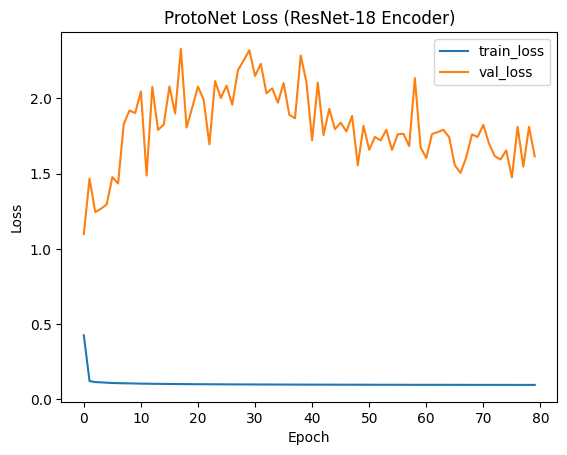

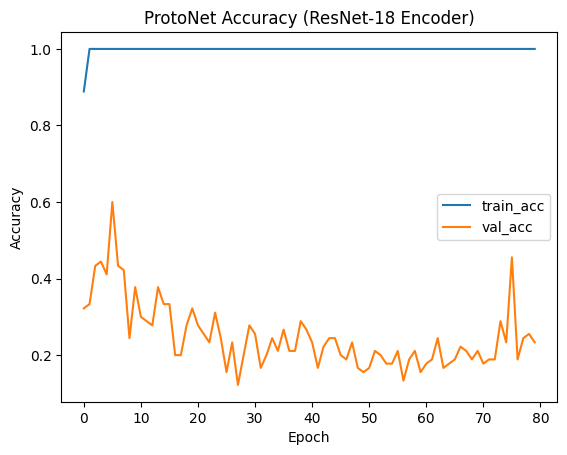

In [ ]:
plt.figure()
plt.plot(train_loss_hist, label="train_loss")
plt.plot(val_loss_hist, label="val_loss")
plt.title("ProtoNet Loss (ResNet-18 Encoder)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(train_acc_hist, label="train_acc")
plt.plot(val_acc_hist, label="val_acc")
plt.title("ProtoNet Accuracy (ResNet-18 Encoder)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


In [ ]:
SAVE_DIR = "/content/drive/MyDrive/sea_turtle_models"
os.makedirs(SAVE_DIR, exist_ok=True)

ENCODER_PATH = os.path.join(SAVE_DIR, "protonet_resnet18_encoder.keras")
encoder.save(ENCODER_PATH)
print("Saved:", ENCODER_PATH)


Saved: /content/drive/MyDrive/sea_turtle_models/protonet_resnet18_encoder.keras
